## TC 5033
### Text Classifier with RNNs

<br>

#### Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch
<br>

- Objective:
    - Understand the basics of Recurrent Neural Networks (RNNs) and their application in text classification.
    - Learn how to handle a real-world text dataset, AG_NEWS, in PyTorch.
    - Gain hands-on experience in defining, training, and evaluating a text classification model in PyTorch.
    
<br>

- Instructions:
    - Data Preparation: Starter code will be provided that loads the AG_NEWS dataset and prepares it for training. Do not modify this part. However, you should be sure to understand it, and comment it, the use of markdown cells is suggested.

    - Model Setup: A skeleton code for the RNN model class will be provided. Complete this class and use it to instantiate your model.

    - Implementing Accuracy Function: Write a function that takes model predictions and ground truth labels as input and returns the model's accuracy.

    - Training Function: Implement a function that performs training on the given model using the AG_NEWS dataset. Your model should achieve an accuracy of at least 80% to get full marks for this part.

    - Text Sampling: Write a function that takes a sample text as input and classifies it using your trained model.

    - Confusion Matrix: Implement a function to display the confusion matrix for your model on the test data.

    - Submission: Submit your completed Jupyter Notebook. Make sure to include a markdown cell at the beginning of the notebook that lists the names of all team members. Teams should consist of 3 to 4 members.
    
<br>

- Evaluation Criteria:

    - Correct setup of all the required libraries and modules (10%)
    - Code Quality (30%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity. Comments should be given for all the provided code, this will help you understand its functionality.
    
   - Functionality (60%):
        - All the functions should execute without errors and provide the expected outputs.
        - RNN model class (20%)
        - Accuracy fucntion (10%)
        - Training function (10%)
        - Sampling function (10%)
        - Confucion matrix (10%)

        - The model should achieve at least an 80% accuracy on the AG_NEWS test set for full marks in this criterion.


Dataset

https://pytorch.org/text/stable/datasets.html#text-classification

https://paperswithcode.com/dataset/ag-news


#### Install libraries (if needed)

You may need to install the following libraries, also you may need to adjust library versions to ensure compatibility, depending on the versions you have previously installed. After installing them, please Restart the Session (Runtime -> Restart Session), or Kernel - Restart Kerne

In [4]:
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.17

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196

In [5]:
!pip install scipy==1.9.3
!pip install scikit-plot
#you may receive a message of restarting session, this is OK

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.4/33.4 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 108.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 2.0.8 requires scipy>=1.10.0, but you have scipy 1.9.3 which is incompatible.
blosc2 3.5.1 requires numpy>=1.26, but you have numpy 1.25.2 which is incompatible.
cvxpy 1.6.6 requires scipy>=1.11.0, but you have scipy 1.9.3 which is incompatible.
imbalanced-learn 0.13.0 re

In [1]:
!pip install portalocker
#please restar session after this intallation. After restarting go straight to importing the libraries

## Import libraries

In [2]:
# The following libraries are required for running the given code
# Please feel free to add any libraries you consider adecuate to complete the assingment.
import numpy as np
#PyTorch libraries
import torch
from torchtext.datasets import AG_NEWS
# Dataloader library
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
# Libraries to prepare the data
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.functional import to_map_style_dataset
# neural layers
from torch import nn
from torch.nn import functional as F

# These libraries are suggested to plot confusion matrix
# you may use others
import scikitplot as skplt
import matplotlib.pyplot as plt
import gc

In [3]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Get the train and the test datasets and dataloaders

Classes:

* 1 - World

* 2 - Sports

* 3 - Business

* 4 - Sci/Tech

We will convert them to:

* 0 - World

* 1 - Sports

* 2 - Business

* 3 - Sci/Tech

In [4]:
train_dataset, test_dataset = AG_NEWS()
train_dataset, test_dataset = to_map_style_dataset(train_dataset), to_map_style_dataset(test_dataset)

In [5]:
# Get the tokeniser
# tokeniser object
tokeniser = get_tokenizer('basic_english')

def yield_tokens(data):
    for _, text in data:
        yield tokeniser(text)

In [6]:
# Build the vocabulary
vocab = build_vocab_from_iterator(yield_tokens(train_dataset), specials=["<unk>"])
#set unknown token at position 0
vocab.set_default_index(vocab["<unk>"])

In [7]:
#test tokens
tokens = tokeniser('Welcome to TC5033')
print(tokens, vocab(tokens))

['welcome', 'to', 'tc5033'] [3314, 4, 0]


In [8]:
NUM_TRAIN = int(len(train_dataset)*0.9)
NUM_VAL = len(train_dataset) - NUM_TRAIN

In [9]:
train_dataset, val_dataset = random_split(train_dataset, [NUM_TRAIN, NUM_VAL])

In [10]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

108000 12000 7600


In [11]:
# function passed to the DataLoader to process a batch of data as indicated
def collate_batch(batch):
    # Get label and text
    y, x = list(zip(*batch))

    # Create list with indices from tokeniser
    x = [vocab(tokeniser(text)) for text in x]
    x = [t + ([0]*(max_tokens - len(t))) if len(t) < max_tokens else t[:max_tokens] for t in x]

    # Prepare the labels, by subtracting 1 to get them in the range 0-3
    return torch.tensor(x, dtype=torch.int32), torch.tensor(y, dtype=torch.int32) - 1

In [12]:
labels =  ["World", "Sports", "Business", "Sci/Tech"]
max_tokens = 50
BATCH_SIZE = 128

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)

### Let us build our RNN model

In [14]:
EMBEDDING_SIZE = 300
NEURONS = 256
LAYERS = 2
NUM_CLASSES = 4

In [15]:
class RNN_Model_1(nn.Module):
    def __init__(self, embed_size, hidden, layers, num_classes):
        super().__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab), embedding_dim=embed_size)

        self.rnn = nn.GRU(embed_size, hidden, num_layers=layers, batch_first=True
                          , bidirectional=True, dropout=0.3
                          )
                        # You may use PyTorch nn.GRU(), nn.RNN(), or nn.LSTM()

        self.fc = nn.Linear(hidden*2,num_classes) # complete output classifier layer using linear layer

    def forward(self, x):
      output, hid = self.rnn(self.embedding_layer(x))

      # For classification, TBD
      avg_pool = torch.mean(output, dim=1)

      return self.fc(avg_pool)
        # implement forward pass. This function will be called when executing the model

In [16]:
def accuracy(model, loader):
  num_correct = 0
  num_total = 0
  model.eval()
  model = model.to(device=device)
  with torch.no_grad():
    for xi, yi in loader:
      xi = xi.to(device=device, dtype = torch.long)
      yi = yi.to(device=device, dtype = torch.long)
      scores = model(xi)
      _, pred = scores.max(dim=1)
      num_correct += (pred == yi).sum().item()
      num_total += pred.size(0)
    return float(num_correct)/num_total

In [17]:
def train(model, optimiser, epochs=100):
  for epoch in range(epochs):
    total_loss = 0.0
    for batch_x, batch_y in train_loader:
      model.train()
      batch_x = batch_x.to(device=device, dtype=torch.long)
      batch_y = batch_y.to(device=device, dtype=torch.long)

      # zero the parameter gradients
      optimiser.zero_grad()

      # forward pass
      output = model(batch_x)

      # loss
      loss = F.cross_entropy(output, batch_y)

      # gradient and update parameters
      loss.backward()
      optimiser.step()


      # Métricas
      total_loss += loss.item()

    acc = accuracy(model, val_loader)
    avg_loss = total_loss/len(train_loader)
    print(f'Epoch: {epoch}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {acc:.4f}')


In [26]:
epochs = 4 # define
lr = .0001 # to do
# instantiate model
rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)
optimiser = torch.optim.Adam(rnn_model.parameters(), lr=lr)

rnn_model = rnn_model.to(device)

In [27]:
train(rnn_model, optimiser=optimiser,  epochs=epochs)

Epoch: 0/4, Loss: 0.6158, Accuracy: 0.8534
Epoch: 1/4, Loss: 0.3294, Accuracy: 0.8861
Epoch: 2/4, Loss: 0.2601, Accuracy: 0.8966
Epoch: 3/4, Loss: 0.2187, Accuracy: 0.8951


In [28]:
print(f'{accuracy(rnn_model, test_loader):.4f}')

0.9025


In [29]:
def sample_text(model, loader):
    x, y = next(iter(loader))
    x = x.to(device=device, dtype=torch.long)
    y = y.to(device=device, dtype=torch.long)

    model.eval() # Set model to evaluation mode

    text =''
    for id_token in x[:1]:
      for id in id_token:
        if vocab.get_itos()[id] != '<unk>':
          text += vocab.get_itos()[id] + ' '
    print(text, '\n')

    with torch.no_grad():
        scores = model(x[:1])
        _, pred = scores.max(dim=1)

    print(f'Predicción: {labels[pred[0]]}, Real: {labels[y[0]]}')

In [30]:
sample_text(rnn_model, test_loader)

warne ends india #39 s teen resistance india posted and trail australia by 275 runs at lunch on the third day of the first test at bangalore . india #39 s two teenagers patel and irfan pathan , who resumed on 18 and one respectively , fought  

Predicción: Sports, Real: Sports


In [45]:
# create confusion matrix
def confusion_matrix(model, loader):

  model.eval()
  model = model.to(device=device)

  all_preds = []
  all_labels = []

  with torch.no_grad():
    for xi, yi in loader:
      xi = xi.to(device=device, dtype = torch.long)
      yi = yi.to(device=device, dtype = torch.long)
      scores = model(xi)
      _, pred = scores.max(dim=1)

      all_preds.extend(pred.cpu().numpy())
      all_labels.extend(yi.cpu().numpy())


  # 3. Plot the confusion matrix
  skplt.metrics.plot_confusion_matrix(all_preds, all_labels, normalize=True)
  plt.show()



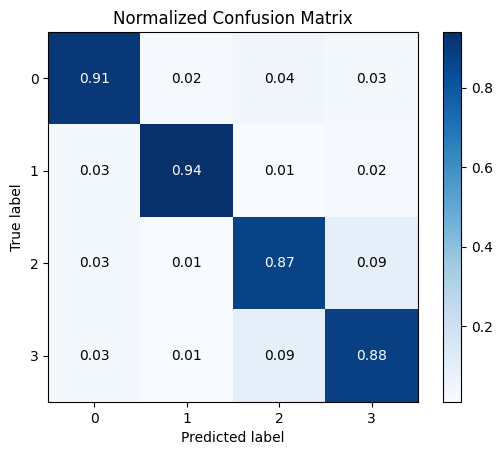

In [46]:
confusion_matrix(rnn_model, test_loader)